# 03 · A/B Test Decision Calculator

**Decision:** determine whether treatment improves conversion and whether the plausible effect clears a business-defined minimum useful lift.

A p-value is evidence about sampling noise—not a shipping rule by itself.


## 1. Example data and scope

The notebook uses a seeded synthetic example with independent random draws for control and treatment. The reusable calculator accepts aggregate counts from other two-arm conversion experiments.


In [1]:
from pathlib import Path
import subprocess, sys

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != '03-ab-test':
    PROJECT_DIR = (PROJECT_DIR / '03-ab-test').resolve()
REPO_ROOT = PROJECT_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = PROJECT_DIR / 'data' / 'ab_data.csv'
if not DATA_PATH.exists():
    subprocess.run([sys.executable, str(PROJECT_DIR / 'generate_data.py')], check=True)

df = pd.read_csv(DATA_PATH)
print(df.groupby('group')['converted'].agg(['count', 'sum', 'mean']))


            count    sum     mean
group                            
control    100000  11522  0.11522
treatment  100000  12704  0.12704


## 2. Validity checks

The statistical test assumes one independent observation per randomized user and a valid binary outcome. In production, also check concurrent exposure, sample-ratio mismatch, bot filtering, and instrumentation.


In [2]:
quality = {
    'rows': len(df),
    'duplicate_user_ids': int(df['user_id'].duplicated().sum()),
    'missing_cells': int(df.isna().sum().sum()),
    'groups': sorted(df['group'].unique().tolist()),
    'conversion_values': sorted(df['converted'].unique().tolist()),
}
quality


{'rows': 200000,
 'duplicate_user_ids': 0,
 'missing_cells': 0,
 'groups': ['control', 'treatment'],
 'conversion_values': [0, 1]}

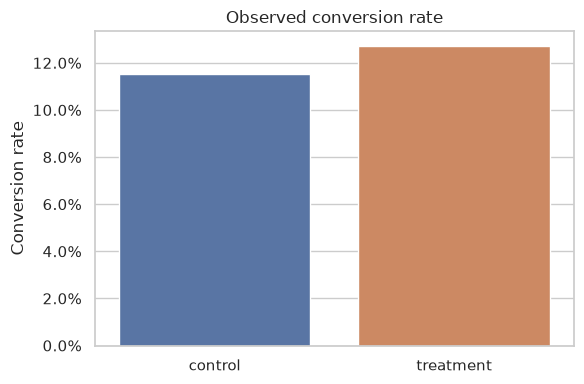

In [3]:
ASSETS = PROJECT_DIR / 'assets'
rates = df.groupby('group', as_index=False)['converted'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=rates, x='group', y='converted', hue='group', legend=False, ax=ax)
ax.set(title='Observed conversion rate', xlabel='', ylabel='Conversion rate')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
fig.tight_layout()
fig.savefig(ASSETS / 'rates.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Statistical and practical significance

Use a two-sided pooled z-test for equality of proportions and an unpooled confidence interval for treatment minus control. The decision also considers a minimum useful absolute lift of 0.5 percentage points.


In [4]:
from portfolio_app.ab_testing import analyze_ab_test, decision

summary = df.groupby('group')['converted'].agg(['count', 'sum'])
result = analyze_ab_test(
    int(summary.loc['control', 'count']),
    int(summary.loc['control', 'sum']),
    int(summary.loc['treatment', 'count']),
    int(summary.loc['treatment', 'sum']),
)
outcome, explanation = decision(result, practical_lift=0.005)

print(f'Control: {result.control_rate:.2%}')
print(f'Treatment: {result.treatment_rate:.2%}')
print(f'Absolute lift: {result.absolute_lift:+.2%}')
print(f'Relative lift: {result.relative_lift:+.1%}')
print(f'z={result.z_score:.3f}, two-sided p={result.p_value:.3g}')
print(f'95% CI for treatment - control: [{result.ci_low:+.2%}, {result.ci_high:+.2%}]')
print(f'Decision: {outcome} — {explanation}')


Control: 11.52%
Treatment: 12.70%
Absolute lift: +1.18%
Relative lift: +10.3%
z=8.101, two-sided p=5.47e-16
95% CI for treatment - control: [+0.90%, +1.47%]
Decision: Ship treatment — The result is statistically significant and the confidence interval clears the minimum useful lift.


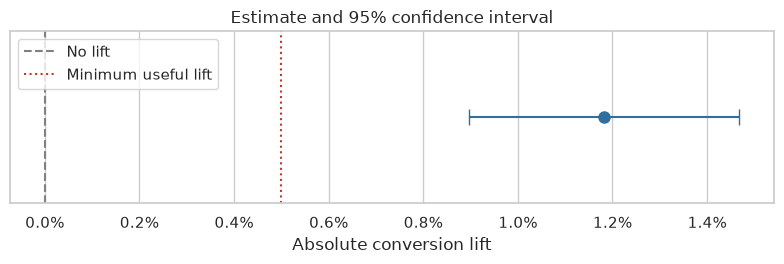

In [5]:
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.errorbar(
    result.absolute_lift, 0,
    xerr=[[result.absolute_lift - result.ci_low], [result.ci_high - result.absolute_lift]],
    fmt='o', color='#2f6f9f', capsize=6, markersize=8,
)
ax.axvline(0, color='grey', linestyle='--', label='No lift')
ax.axvline(0.005, color='#c0392b', linestyle=':', label='Minimum useful lift')
ax.set(yticks=[], xlabel='Absolute conversion lift', title='Estimate and 95% confidence interval')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(ASSETS / 'lift_ci.png', dpi=160, bbox_inches='tight')
plt.show()


## 4. Plan sample size before launch

Power analysis should be based on the smallest effect worth detecting, not the effect observed after the test.


In [6]:
from portfolio_app.ab_testing import required_sample_per_arm

planning = pd.DataFrame([
    {'baseline': 0.10, 'relative_mde': mde, 'power': power,
     'required_per_arm': required_sample_per_arm(0.10, mde, power=power)}
    for mde in [0.05, 0.10, 0.15]
    for power in [0.80, 0.90]
])
planning.style.format({'baseline': '{:.1%}', 'relative_mde': '{:.0%}', 'power': '{:.0%}', 'required_per_arm': '{:,.0f}'})


,baseline,relative_mde,power,required_per_arm
0,10.0%,5%,80%,"57,756"
1,10.0%,5%,90%,"77,319"
2,10.0%,10%,80%,"14,745"
3,10.0%,10%,90%,"19,739"
4,10.0%,15%,80%,"6,687"
5,10.0%,15%,90%,"8,951"


## 5. Controlled stakeholder brief

The text layer receives only validated counts, calculated statistics, the practical threshold, and the analyst's recommendation context.


In [7]:
from utils.ai_insights import generate_insights

brief = generate_insights({
    'headline': (
        f'Treatment converted at {result.treatment_rate:.2%} versus {result.control_rate:.2%} '
        f'for control. Absolute lift is {result.absolute_lift:+.2%}, p={result.p_value:.3g}, '
        f'and the 95% CI is [{result.ci_low:+.2%}, {result.ci_high:+.2%}].'
    ),
    'drivers': [
        'Observed conversions and sample sizes',
        'Sampling uncertainty represented by the confidence interval',
        'Minimum useful lift of 0.5 percentage points',
    ],
    'recommendation': (
        f'{outcome}. Confirm randomization quality, experiment duration, revenue, refunds, '
        'and other guardrail metrics before rollout.'
    ),
})
content = '# AI-assisted stakeholder brief — A/B Test\n\n' + brief + '\n'
(PROJECT_DIR / 'insights.md').write_text(content, encoding='utf-8')
print(brief)


## What the data says
Treatment converted at 12.70% versus 11.52% for control. Absolute lift is +1.18%, p=5.47e-16, and the 95% CI is [+0.90%, +1.47%].

## Factors to review
- Observed conversions and sample sizes
- Sampling uncertainty represented by the confidence interval
- Minimum useful lift of 0.5 percentage points

## Recommended action
Ship treatment. Confirm randomization quality, experiment duration, revenue, refunds, and other guardrail metrics before rollout.


## 6. Assumptions and limitations

- Users are independently randomized, appear once, and variants run concurrently.
- The outcome and analysis window were defined before inspecting the result.
- Sample sizes are large enough for the normal approximation.
- Repeatedly checking a fixed-horizon p-value inflates false positives; use a pre-committed horizon or a sequential design.
- Conversion should be reviewed with guardrails such as revenue, refunds, support contacts, or latency.
